# Modeling — Wide & Deep · Opsi 2 (Category-based Label)

**Perbedaan mendasar dari versi sebelumnya:**

| | Versi lama | Versi Opsi 2 |
|---|---|---|
| **Dasar label** | `avg_ratio` (circular) | `pct_kebutuhan` (distribusi kategori) |
| **avg_ratio** | Masuk sebagai fitur model | **Tidak masuk model** |
| **Fitur model** | 28 termasuk avg_ratio | 24 tanpa avg_ratio |
| **Model belajar** | Threshold yang kita buat | Pola distribusi kategori + volatilitas |

**Mengapa ini lebih valid:** Model harus menyimpulkan persona dari *bagaimana* user
membelanjakan uangnya (kemana), bukan dari *seberapa banyak* (yang sudah jadi label).

---

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json, os, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (Dense, Embedding, Flatten,
    Concatenate, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                         ReduceLROnPlateau)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_class_weight
import joblib

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

PALETTE = {'saver':'#2ecc71','balanced':'#3498db','spender':'#f39c12'}
ORDER   = ['saver','balanced','spender']

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


## 2. Load Data & Threshold

In [ ]:
df = pd.read_csv('raw_dataset_personal_finance.csv')
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.drop(columns=['status_user'])

with open('persona_thresholds.json') as f:
    thresh = json.load(f)

P33  = thresh['p33_pct_kebutuhan']
P67  = thresh['p67_pct_kebutuhan']
OVER = thresh['overspending_threshold']
KEBUTUHAN_CATS  = thresh['kebutuhan_categories']
GAYAHIDUP_CATS  = thresh['gayahidup_categories']

print('Threshold dari EDA (Opsi 2):')
print(f'  saver       : pct_kebutuhan >= {P67:.6f}')
print(f'  balanced    : {P33:.6f} < pct_kebutuhan < {P67:.6f}')
print(f'  spender     : pct_kebutuhan <= {P33:.6f}')
print(f'  overspending: avg_ratio >= {OVER} (rule, tidak dilatih)')
print()
print(f'Kebutuhan pokok : {KEBUTUHAN_CATS}')
print(f'Gaya hidup      : {GAYAHIDUP_CATS}')

Threshold dari EDA (Opsi 2):
  saver       : pct_kebutuhan >= 0.434930
  balanced    : 0.420485 < pct_kebutuhan < 0.434930
  spender     : pct_kebutuhan <= 0.420485
  overspending: avg_ratio >= 1.0 (rule, tidak dilatih)

Kebutuhan pokok : ['Perumahan', 'Makanan', 'Kesehatan', 'Tagihan', 'Transportasi']
Gaya hidup      : ['Hiburan', 'Belanja', 'Traveling', 'Pakaian', 'Elektronik', 'Olahraga', 'Sosial', 'Hewan Peliharaan', 'Anak-Anak', 'Pendidikan']


## 3. Feature Engineering (tanpa avg_ratio)

In [ ]:
# Monthly aggregate
user_monthly = df.groupby(['id_pengguna','bulan','tahun']).agg(
    total_keluar=('jumlah_pengeluaran','sum'),
    pendapatan=('pendapatan_bulanan','first'),
    n_transaksi=('jumlah_pengeluaran','count')
).reset_index()
user_monthly['monthly_ratio'] = user_monthly['total_keluar'] / user_monthly['pendapatan']
user_monthly_s = user_monthly.sort_values(['id_pengguna','tahun','bulan'])

# Stats per user — avg_ratio dihitung tapi tidak masuk MODEL_FEATS
user_stats = user_monthly.groupby('id_pengguna').agg(
    avg_ratio    =('monthly_ratio','mean'),
    std_ratio    =('monthly_ratio','std'),
    min_ratio    =('monthly_ratio','min'),
    max_ratio    =('monthly_ratio','max'),
    avg_keluar   =('total_keluar','mean'),
    std_keluar   =('total_keluar','std'),
    avg_transaksi=('n_transaksi','mean'),
).reset_index().fillna(0)
user_stats['ratio_range'] = user_stats['max_ratio'] - user_stats['min_ratio']

last3  = user_monthly_s.groupby('id_pengguna').tail(3)         .groupby('id_pengguna')['monthly_ratio'].mean()
first3 = user_monthly_s.groupby('id_pengguna').head(3)         .groupby('id_pengguna')['monthly_ratio'].mean()
user_stats['trend'] = (last3 - first3).values

# Category ratios
grand = df.groupby('id_pengguna')['jumlah_pengeluaran'].sum().reset_index()
grand.columns = ['id_pengguna','grand_total']
cat = df.groupby(['id_pengguna','Kategori'])['jumlah_pengeluaran'].sum().reset_index()
cat = cat.merge(grand, on='id_pengguna')
cat['cat_ratio'] = cat['jumlah_pengeluaran'] / cat['grand_total']
cat_pivot = cat.pivot_table(index='id_pengguna', columns='Kategori',
                             values='cat_ratio', fill_value=0).reset_index()
cat_pivot.columns = ['id_pengguna' if c=='id_pengguna' else f'cat_{c}'
                     for c in cat_pivot.columns]
CAT_COLS = [c for c in cat_pivot.columns if c!='id_pengguna']

identity = df.groupby('id_pengguna')[['pendapatan_bulanan','Kota']].first().reset_index()

user_full = (user_stats
    .merge(cat_pivot, on='id_pengguna')
    .merge(identity, on='id_pengguna'))

# pct_kebutuhan dan pct_gaya_hidup
kebutuhan_cols = [f'cat_{c}' for c in KEBUTUHAN_CATS if f'cat_{c}' in user_full.columns]
gayahidup_cols = [f'cat_{c}' for c in GAYAHIDUP_CATS if f'cat_{c}' in user_full.columns]
user_full['pct_kebutuhan']  = user_full[kebutuhan_cols].sum(axis=1)
user_full['pct_gaya_hidup'] = user_full[gayahidup_cols].sum(axis=1)

print('user_full shape:', user_full.shape)

user_full shape: (573, 29)


## 4. Labeling & Filter Overspending

In [ ]:
def assign_persona(row):
    if row['avg_ratio'] >= OVER:        return 'overspending'
    elif row['pct_kebutuhan'] >= P67:   return 'saver'
    elif row['pct_kebutuhan'] <= P33:   return 'spender'
    else:                               return 'balanced'

user_full['persona'] = user_full.apply(assign_persona, axis=1)
print('Distribusi semua persona:')
print(user_full['persona'].value_counts())

Distribusi semua persona:
persona
spender         176
balanced        158
saver           155
overspending     84
Name: count, dtype: int64


User masuk model  (3 kelas): 489
User overspending (rule)   : 84

Distribusi 3 kelas model:
persona
spender     176
balanced    158
saver       155
Name: count, dtype: int64


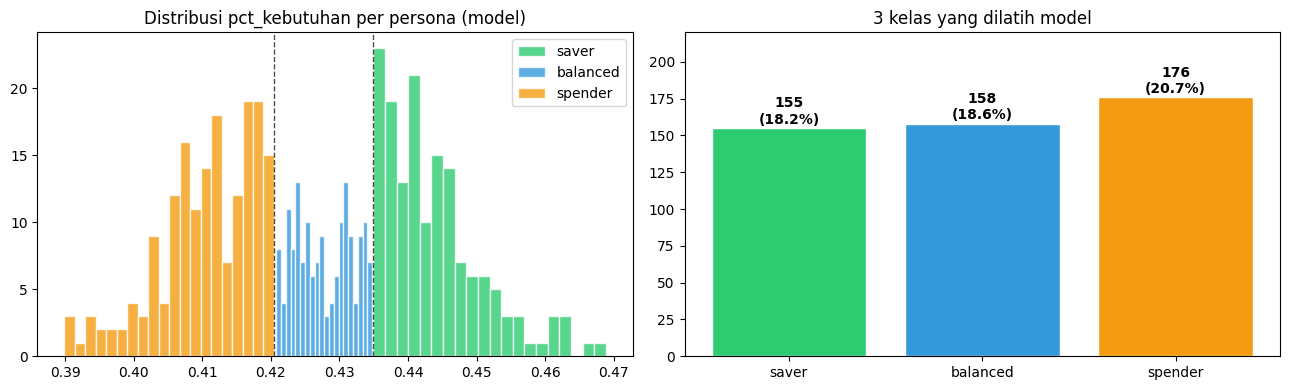

In [ ]:
# Filter: pisahkan overspending sebelum training
mask_model = user_full['avg_ratio'] < OVER
user_model = user_full[mask_model].copy().reset_index(drop=True)
user_over  = user_full[~mask_model].copy()

print(f'User masuk model  (3 kelas): {len(user_model)}')
print(f'User overspending (rule)   : {len(user_over)}')
print()
print('Distribusi 3 kelas model:')
dist3 = user_model['persona'].value_counts()
print(dist3)

fig, axes = plt.subplots(1, 2, figsize=(13,4))
for p, color in PALETTE.items():
    mask = user_model['persona'] == p
    axes[0].hist(user_model.loc[mask,'pct_kebutuhan'], bins=20,
                 color=color, edgecolor='white', alpha=0.8, label=p)
axes[0].axvline(P33, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[0].axvline(P67, color='black', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Distribusi pct_kebutuhan per persona (model)')
axes[0].legend()

counts = [dist3.get(p,0) for p in ORDER]
bars = axes[1].bar(ORDER, counts, color=[PALETTE[p] for p in ORDER], edgecolor='white')
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{cnt}\n({cnt/850*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('3 kelas yang dilatih model')
axes[1].set_ylim(0, max(counts)*1.25)
plt.tight_layout()
plt.savefig('model_01_label_distribusi.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Preprocessing

In [ ]:
# Fitur model — avg_ratio dan turunannya TIDAK masuk
MODEL_FEATS = (
    ['std_ratio','ratio_range','trend',
     'avg_keluar','std_keluar','avg_transaksi',
     'pendapatan_bulanan','pct_kebutuhan','pct_gaya_hidup']
    + CAT_COLS
)

print(f'Total fitur model: {len(MODEL_FEATS)}')
print(f'  - volatilitas/tren: std_ratio, ratio_range, trend')
print(f'  - pengeluaran abs  : avg_keluar, std_keluar, avg_transaksi')
print(f'  - konteks          : pendapatan_bulanan')
print(f'  - kategori summary : pct_kebutuhan, pct_gaya_hidup')
print(f'  - category ratios  : {len(CAT_COLS)} kolom')
print()
print('TIDAK masuk model: avg_ratio, min_ratio, max_ratio')
print('  → ini yang jadi dasar rule overspending & validasi')

Total fitur model: 24
  - volatilitas/tren: std_ratio, ratio_range, trend
  - pengeluaran abs  : avg_keluar, std_keluar, avg_transaksi
  - konteks          : pendapatan_bulanan
  - kategori summary : pct_kebutuhan, pct_gaya_hidup
  - category ratios  : 15 kolom

TIDAK masuk model: avg_ratio, min_ratio, max_ratio
  → ini yang jadi dasar rule overspending & validasi


In [ ]:
le_persona = LabelEncoder()
user_model['persona_enc'] = le_persona.fit_transform(user_model['persona'])
print('Mapping persona:', dict(zip(le_persona.classes_, range(len(le_persona.classes_)))))
N_CLASSES = 3

# Fit kota di semua data (bukan hanya model) agar kota baru tetap bisa diencode
le_kota = LabelEncoder()
le_kota.fit(df['Kota'])
user_model['kota_enc'] = le_kota.transform(user_model['Kota'])
N_KOTA = len(le_kota.classes_)
print(f'Kota unik: {N_KOTA}')

Mapping persona: {'balanced': 0, 'saver': 1, 'spender': 2}
Kota unik: 56


In [ ]:
X_num  = user_model[MODEL_FEATS].values
X_kota = user_model['kota_enc'].values
y      = user_model['persona_enc'].values

X_ntr, X_ntmp, X_ktr, X_ktmp, y_tr, y_tmp = train_test_split(
    X_num, X_kota, y, test_size=0.30, random_state=SEED, stratify=y)
X_nval, X_nte, X_kval, X_kte, y_val, y_te = train_test_split(
    X_ntmp, X_ktmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

print(f'Train: {len(y_tr)} | Val: {len(y_val)} | Test: {len(y_te)}')
for name, arr in [('Train',y_tr),('Val',y_val),('Test',y_te)]:
    vals, counts = np.unique(arr, return_counts=True)
    print(f'  {name}: {dict(zip(le_persona.classes_[vals], counts.tolist()))}')

Train: 342 | Val: 73 | Test: 74
  Train: {'balanced': 111, 'saver': 108, 'spender': 123}
  Val: {'balanced': 23, 'saver': 24, 'spender': 26}
  Test: {'balanced': 24, 'saver': 23, 'spender': 27}


In [ ]:
scaler = StandardScaler()
X_ntr  = scaler.fit_transform(X_ntr)
X_nval = scaler.transform(X_nval)
X_nte  = scaler.transform(X_nte)
N_NUM  = X_ntr.shape[1]
print('Shape train numerik:', X_ntr.shape)

cw_arr  = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
cw_dict = dict(enumerate(cw_arr))
print('Class weights:')
for idx, cls in enumerate(le_persona.classes_):
    print(f'  {cls:<10}: {cw_dict[idx]:.4f}')

Shape train numerik: (342, 24)
Class weights:
  balanced  : 1.0270
  saver     : 1.0556
  spender   : 0.9268


## 6. Wide & Deep Model (3 kelas)

In [ ]:
def build_wide_and_deep(n_num, n_kota, n_classes=3, embed_dim=8):
    num_input  = Input(shape=(n_num,), name='numerical')
    kota_input = Input(shape=(1,),     name='kota')

    # Wide path — linear memorization
    wide = Dense(32, activation='relu', name='wide_dense')(num_input)

    # Deep path — non-linear generalization + embedding kota
    kota_emb = Embedding(n_kota, embed_dim, name='kota_embedding')(kota_input)
    kota_emb = Flatten(name='kota_flatten')(kota_emb)
    deep = Concatenate(name='deep_concat')([num_input, kota_emb])
    deep = Dense(128, activation='relu', name='deep_1')(deep)
    deep = BatchNormalization(name='bn_1')(deep)
    deep = Dropout(0.35, name='drop_1')(deep)
    deep = Dense(64, activation='relu', name='deep_2')(deep)
    deep = BatchNormalization(name='bn_2')(deep)
    deep = Dropout(0.25, name='drop_2')(deep)
    deep = Dense(32, activation='relu', name='deep_3')(deep)

    combined = Concatenate(name='wide_deep_concat')([wide, deep])
    combined = Dropout(0.2, name='drop_final')(combined)
    output   = Dense(n_classes, activation='softmax', name='output')(combined)

    model = Model(inputs=[num_input, kota_input], outputs=output,
                  name='WideAndDeep_Opsi2')
    return model

model = build_wide_and_deep(N_NUM, N_KOTA)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
print(f'Total parameter: {model.count_params():,}')

Model: "WideAndDeep_Opsi2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ kota (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kota_embedding      │ (None, 1, 8)      │        448 │ kota[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical           │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kota_flatten        │ (None, 8)         │          0 │ kota_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_concat         │ (None, 32)        │          0 │ numerical[0][0],  │
│ (Concatenate)       │                   │            │ kota_flatten[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_1 (Dense)      │ (None, 128)       │      4,224 │ deep_concat[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 128)       │        512 │ deep_1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_1 (Dropout)    │ (None, 128)       │          0 │ bn_1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_2 (Dense)      │ (None, 64)        │      8,256 │ drop_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 64)        │        256 │ deep_2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_2 (Dropout)    │ (None, 64)        │          0 │ bn_2[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_dense (Dense)  │ (None, 32)        │        800 │ numerical[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ deep_3 (Dense)      │ (None, 32)        │      2,080 │ drop_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ wide_deep_concat    │ (None, 64)        │          0 │ wide_dense[0][0], │
│ (Concatenate)       │                   │            │ deep_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_final          │ (None, 64)        │          0 │ wide_deep_concat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ drop_final[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,771 (65.51 KB)

 Trainable params: 16,387 (64.01 KB)

 Non-trainable params: 384 (1.50 KB)

Total parameter: 16,771


## 7. Training

In [ ]:
os.makedirs('checkpoints', exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=25,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('checkpoints/best_opsi2.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=10, min_lr=1e-6, verbose=1),
]

history = model.fit(
    x={'numerical': X_ntr, 'kota': X_ktr},
    y=y_tr,
    validation_data=({'numerical': X_nval, 'kota': X_kval}, y_val),
    epochs=250, batch_size=32,
    class_weight=cw_dict,
    callbacks=callbacks,
    verbose=1
)
print(f'\nBest val_accuracy: {max(history.history["val_accuracy"]):.4f}')

Epoch 1/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.4327 - loss: 1.1682 - val_accuracy: 0.7260 - val_loss: 0.8850 - learning_rate: 0.0010
Epoch 2/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5673 - loss: 0.8940 - val_accuracy: 0.7534 - val_loss: 0.7881 - learning_rate: 0.0010
Epoch 3/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6813 - loss: 0.7183 - val_accuracy: 0.7671 - val_loss: 0.7136 - learning_rate: 0.0010
Epoch 4/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6930 - loss: 0.6619 - val_accuracy: 0.8082 - val_loss: 0.6517 - learning_rate: 0.0010
Epoch 5/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7485 - loss: 0.5921 - val_accuracy: 0.8630 - val_loss: 0.5983 - learning_rate: 0.0010
Epoch 6/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7661 - loss: 0.5207 - val_accuracy: 0.8630 - val_loss: 0.5524 - learning_rate: 0.0010
Epoch 7/250
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7749 - loss: 0.4973 -

## 8. Evaluasi

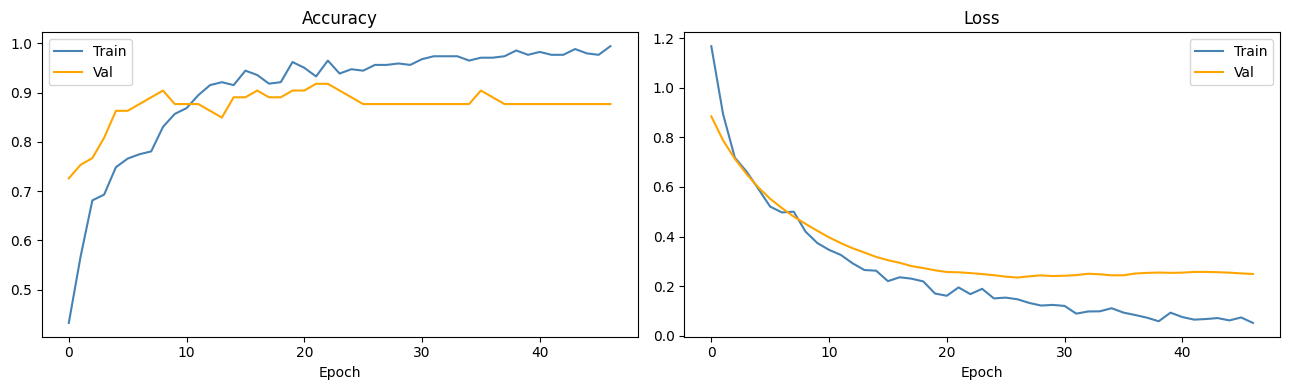

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue', linewidth=1.5)
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange',    linewidth=1.5)
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history.history['loss'],     label='Train', color='steelblue', linewidth=1.5)
axes[1].plot(history.history['val_loss'], label='Val',   color='orange',    linewidth=1.5)
axes[1].set_title('Loss'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('model_02_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(
    {'numerical': X_nte, 'kota': X_kte}, y_te, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

y_pred_proba = model.predict({'numerical': X_nte, 'kota': X_kte}, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

print()
print('Classification Report:')
print(classification_report(y_te, y_pred, target_names=le_persona.classes_))

Test Loss    : 0.2645
Test Accuracy: 0.9054  (90.54%)

Classification Report:
              precision    recall  f1-score   support

    balanced       0.87      0.83      0.85        24
       saver       0.88      0.96      0.92        23
     spender       0.96      0.93      0.94        27

    accuracy                           0.91        74
   macro avg       0.90      0.91      0.90        74
weighted avg       0.91      0.91      0.91        74



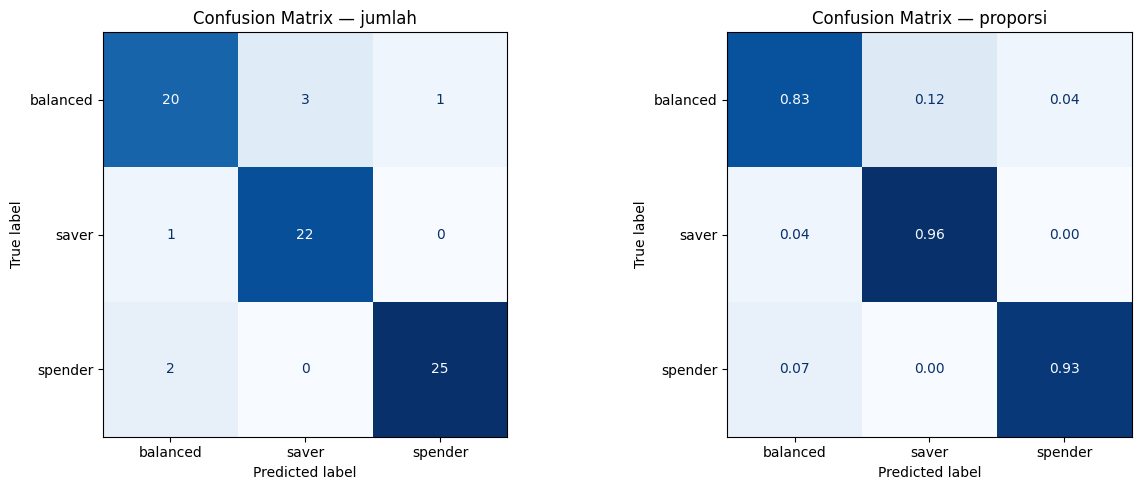

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
cm = confusion_matrix(y_te, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le_persona.classes_).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — jumlah')

cm_norm = confusion_matrix(y_te, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=le_persona.classes_).plot(
    ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title('Confusion Matrix — proporsi')
plt.tight_layout()
plt.savefig('model_03_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

Top 15 fitur:
pct_kebutuhan           0.2027
pct_gaya_hidup          0.1081
cat_Belanja             0.0811
cat_Perumahan           0.0811
cat_Transportasi        0.0541
cat_Hewan Peliharaan    0.0405
cat_Olahraga            0.0405
cat_Anak-Anak           0.0405
cat_Tagihan             0.0270
cat_Pakaian             0.0270
pendapatan_bulanan      0.0270
cat_Hiburan             0.0270
trend                   0.0135
avg_keluar              0.0135
cat_Elektronik          0.0135
dtype: float64


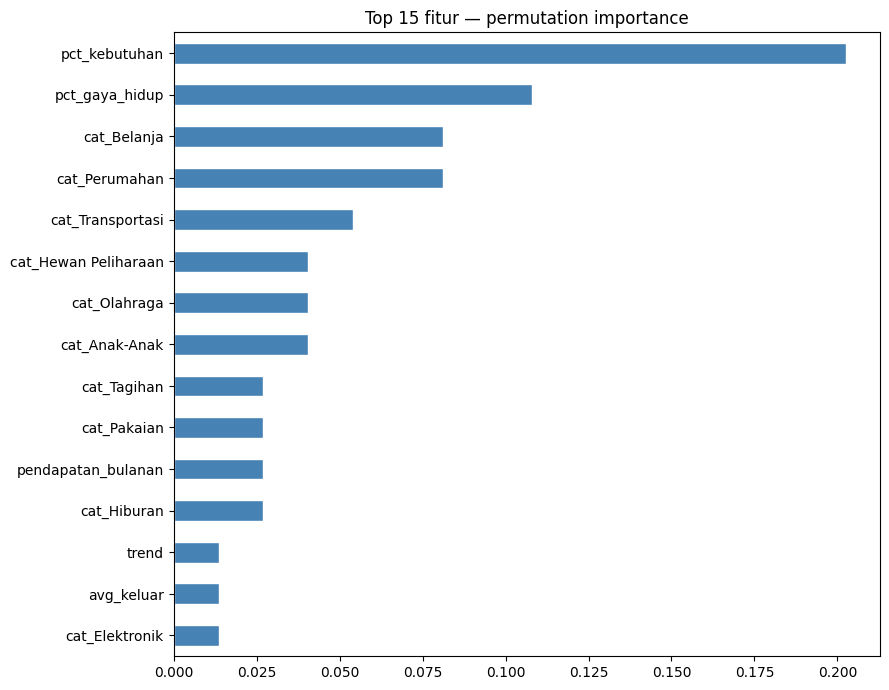

In [ ]:
# Permutation importance
baseline_acc = test_acc
importances  = {}
for i, col in enumerate(MODEL_FEATS):
    X_tmp = X_nte.copy()
    np.random.shuffle(X_tmp[:, i])
    _, acc_perm = model.evaluate(
        {'numerical': X_tmp, 'kota': X_kte}, y_te, verbose=0)
    importances[col] = baseline_acc - acc_perm

imp_df = pd.Series(importances).sort_values(ascending=False)
print('Top 15 fitur:')
print(imp_df.head(15).round(4))

fig, ax = plt.subplots(figsize=(9,7))
imp_df.head(15).plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 fitur — permutation importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('model_04_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Simpan Artifacts

In [ ]:
os.makedirs('artifacts', exist_ok=True)

model.save('artifacts/wide_and_deep_opsi2.keras')
joblib.dump(scaler,    'artifacts/scaler.pkl')
joblib.dump(le_persona,'artifacts/le_persona.pkl')
joblib.dump(le_kota,   'artifacts/le_kota.pkl')

metadata = {
    'model_file'            : 'wide_and_deep_opsi2.keras',
    'labeling_method'       : 'opsi2_category_based',
    'model_feats'           : MODEL_FEATS,
    'cat_cols'              : CAT_COLS,
    'kebutuhan_cats'        : [f'cat_{c}' for c in KEBUTUHAN_CATS],
    'gayahidup_cats'        : [f'cat_{c}' for c in GAYAHIDUP_CATS],
    'n_num_features'        : N_NUM,
    'n_kota'                : N_KOTA,
    'n_classes'             : N_CLASSES,
    'persona_classes'       : le_persona.classes_.tolist(),
    'embed_dim'             : 8,
    'p33_pct_kebutuhan'     : float(P33),
    'p67_pct_kebutuhan'     : float(P67),
    'overspending_threshold': float(OVER),
    'test_accuracy'         : float(test_acc),
    'test_loss'             : float(test_loss),
    'note'                  : (
        'Label dari distribusi kategori (opsi2). '
        'avg_ratio tidak masuk fitur model. '
        'overspending = rule avg_ratio >= 1.0'
    )
}
with open('artifacts/metadata.json','w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('Artifacts tersimpan:')
for fname in sorted(os.listdir('artifacts')):
    sz = os.path.getsize(f'artifacts/{fname}')
    print(f'  {fname:<40} {sz:>8,} bytes')

Artifacts tersimpan:
  le_kota.pkl                                 1,101 bytes
  le_persona.pkl                                502 bytes
  metadata.json                               1,768 bytes
  scaler.pkl                                  1,191 bytes
  wide_and_deep_opsi2.keras                 269,788 bytes


## 10. Fungsi Inference

In [ ]:
ALL_CATEGORIES = ['Anak-Anak','Belanja','Elektronik','Hewan Peliharaan','Hiburan',
                  'Kesehatan','Makanan','Olahraga','Pakaian','Pendidikan',
                  'Perumahan','Sosial','Tagihan','Transportasi','Traveling']

def load_artifacts(d='artifacts'):
    m   = tf.keras.models.load_model(f'{d}/wide_and_deep_opsi2.keras')
    sc  = joblib.load(f'{d}/scaler.pkl')
    lep = joblib.load(f'{d}/le_persona.pkl')
    lek = joblib.load(f'{d}/le_kota.pkl')
    with open(f'{d}/metadata.json') as f:
        meta = json.load(f)
    return m, sc, lep, lek, meta

def build_features(df_u, meta):
    """Bangun feature vector dari DataFrame transaksi satu user."""
    um = df_u.groupby(['bulan','tahun']).agg(
        total_keluar=('jumlah_pengeluaran','sum'),
        pendapatan=('pendapatan_bulanan','first'),
        n_transaksi=('jumlah_pengeluaran','count')
    ).reset_index()
    um['monthly_ratio'] = um['total_keluar'] / um['pendapatan']
    um = um.sort_values(['tahun','bulan'])

    avg_ratio = float(um['monthly_ratio'].mean())
    grand     = df_u['jumlah_pengeluaran'].sum()

    feats = {
        'std_ratio'         : float(um['monthly_ratio'].std() or 0),
        'ratio_range'       : float(um['monthly_ratio'].max() - um['monthly_ratio'].min()),
        'trend'             : float(um.tail(3)['monthly_ratio'].mean() -
                                    um.head(3)['monthly_ratio'].mean()),
        'avg_keluar'        : float(um['total_keluar'].mean()),
        'std_keluar'        : float(um['total_keluar'].std() or 0),
        'avg_transaksi'     : float(um['n_transaksi'].mean()),
        'pendapatan_bulanan': float(df_u['pendapatan_bulanan'].iloc[0]),
    }

    # Category ratios
    for cat in ALL_CATEGORIES:
        val = df_u[df_u['Kategori']==cat]['jumlah_pengeluaran'].sum()
        feats[f'cat_{cat}'] = float(val/grand) if grand > 0 else 0.0

    # Aggregated category groups
    kebutuhan_cols  = meta['kebutuhan_cats']
    gayahidup_cols  = meta['gayahidup_cats']
    feats['pct_kebutuhan']  = sum(feats.get(c, 0) for c in kebutuhan_cols)
    feats['pct_gaya_hidup'] = sum(feats.get(c, 0) for c in gayahidup_cols)

    return feats, avg_ratio

def predict_persona(transactions, model_, scaler_, le_p_, le_k_, meta_):
    df_u = pd.DataFrame(transactions)
    feats, avg_ratio = build_features(df_u, meta_)

    cat_totals = df_u.groupby('Kategori')['jumlah_pengeluaran']                     .sum().sort_values(ascending=False)
    base = {
        'avg_monthly_ratio': round(avg_ratio, 4),
        'spending_trend'   : round(feats['trend'], 4),
        'pct_kebutuhan'    : round(feats['pct_kebutuhan'], 4),
        'pct_gaya_hidup'   : round(feats['pct_gaya_hidup'], 4),
        'pendapatan'       : int(feats['pendapatan_bulanan']),
        'kota'             : df_u['Kota'].iloc[0],
        'top_category'     : {'nama': cat_totals.index[0], 'total': int(cat_totals.iloc[0])},
        'bot_category'     : {'nama': cat_totals.index[-1], 'total': int(cat_totals.iloc[-1])},
    }

    # Rule check dulu
    if avg_ratio >= meta_['overspending_threshold']:
        return {**base,
                'persona'   : 'overspending',
                'confidence': 1.0,
                'proba'     : {'overspending':1.0,'saver':0.0,'balanced':0.0,'spender':0.0},
                'method'    : 'rule'}

    # Model
    x_num  = np.array([[feats[c] for c in meta_['model_feats']]])
    x_num  = scaler_.transform(x_num)
    try:    kota_enc = int(le_k_.transform([df_u['Kota'].iloc[0]])[0])
    except: kota_enc = 0
    x_kota = np.array([[kota_enc]])

    proba    = model_.predict({'numerical': x_num, 'kota': x_kota}, verbose=0)[0]
    pred_idx = int(np.argmax(proba))
    persona  = le_p_.inverse_transform([pred_idx])[0]

    return {**base,
            'persona'   : persona,
            'confidence': round(float(proba[pred_idx]), 4),
            'proba'     : {c: round(float(p), 4)
                           for c, p in zip(le_p_.classes_, proba)},
            'method'    : 'model'}

print('Fungsi inference siap.')

Fungsi inference siap.


In [ ]:
# Test inference
df_orig = pd.read_csv('raw_dataset_personal_finance.csv').drop(columns=['status_user'])
m_inf, sc_inf, lep_inf, lek_inf, meta_inf = load_artifacts()

sample = df_orig[df_orig['id_pengguna']=='USR000001'][
    ['bulan','tahun','Kota','Kategori','pendapatan_bulanan','jumlah_pengeluaran']
].to_dict('records')

result = predict_persona(sample, m_inf, sc_inf, lep_inf, lek_inf, meta_inf)
print('Prediksi USR000001:')
for k,v in result.items():
    print(f'  {k:<22}: {v}')

Prediksi USR000001:
  avg_monthly_ratio     : 0.6142
  spending_trend        : -0.1024
  pct_kebutuhan         : 0.4105
  pct_gaya_hidup        : 0.5895
  pendapatan            : 13788000
  kota                  : Makassar
  top_category          : {'nama': 'Perumahan', 'total': 10815000}
  bot_category          : {'nama': 'Olahraga', 'total': 4144000}
  persona               : spender
  confidence            : 0.9987
  proba                 : {'balanced': 0.0013, 'saver': 0.0, 'spender': 0.9987}
  method                : model


In [ ]:
print('='*60)
print('  RINGKASAN — Wide & Deep Opsi 2')
print('='*60)
print(f'  Labeling       : distribusi kategori (bukan avg_ratio)')
print(f'  avg_ratio      : TIDAK masuk fitur model')
print(f'  Model classes  : {N_CLASSES} (saver / balanced / spender)')
print(f'  Overspending   : rule avg_ratio >= {OVER}')
print(f'  Training data  : {len(y_tr)} user')
print(f'  Total fitur    : {N_NUM} numerik + embedding Kota')
print(f'  Total params   : {model.count_params():,}')
print(f'  Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Test Loss      : {test_loss:.4f}')
print('='*60)

  RINGKASAN — Wide & Deep Opsi 2
  Labeling       : distribusi kategori (bukan avg_ratio)
  avg_ratio      : TIDAK masuk fitur model
  Model classes  : 3 (saver / balanced / spender)
  Overspending   : rule avg_ratio >= 1.0
  Training data  : 342 user
  Total fitur    : 24 numerik + embedding Kota
  Total params   : 16,771
  Test Accuracy  : 0.9054  (90.54%)
  Test Loss      : 0.2645
